In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")

**Load Dataset**

In [ ]:
df = pd.read_csv("student-mat.csv", sep=';')
print(df)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health 

In [ ]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Cleaning Dataset**

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
df = df.drop_duplicates()
print(df)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health 

In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (395, 33)

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


**Analysis of Data**

In [ ]:
# 1. Average final grade
avg_grade = df['G3'].mean()
print("\nAverage Final Grade (G3):", avg_grade)


Average Final Grade (G3): 10.415189873417722


In [ ]:
# 2. Students scoring above 15
above_15 = df[df['G3'] > 15].shape[0]
print("Students scoring above 15:", above_15)

Students scoring above 15: 40


In [ ]:
# 3. Correlation between study time and performance
correlation = df['studytime'].corr(df['G3'])
print("Correlation (Study Time vs G3):", correlation)

Correlation (Study Time vs G3): 0.09781968965319626


In [ ]:
# 4. Gender performance comparison
gender_avg = df.groupby('sex')['G3'].mean()
print("\nAverage score by gender:")
print(gender_avg)


Average score by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


**Visualization**

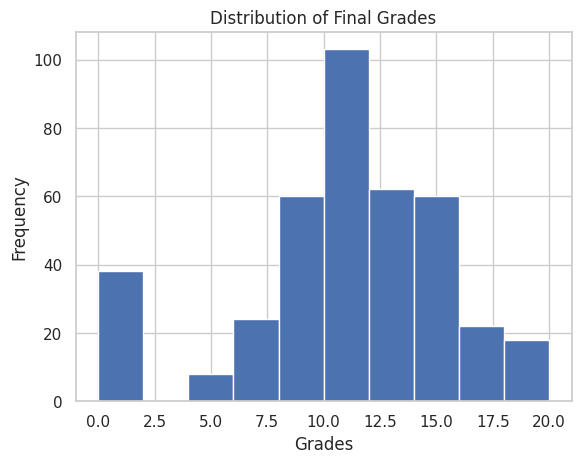

In [ ]:
#  Histogram of grades
plt.figure()
plt.hist(df['G3'], bins=10)
plt.title("Distribution of Final Grades")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.show()

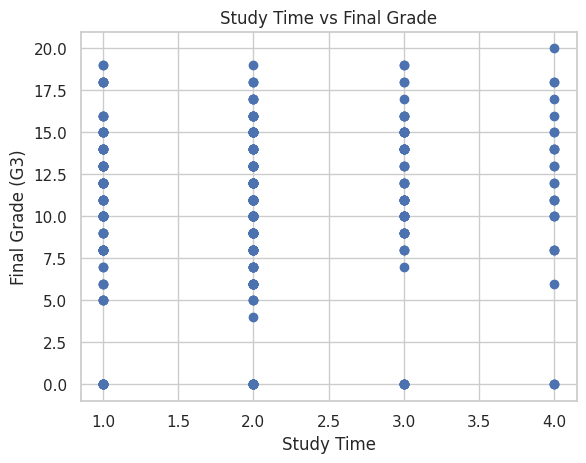

In [ ]:
#  Scatter plot (study time vs grades)
plt.figure()
plt.scatter(df['studytime'], df['G3'])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.show()


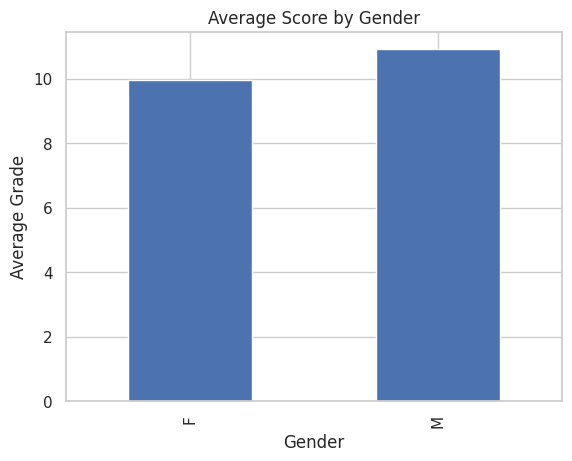

In [ ]:
#  Bar chart (gender vs average score)
plt.figure()
gender_avg.plot(kind='bar')
plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade")
plt.show()

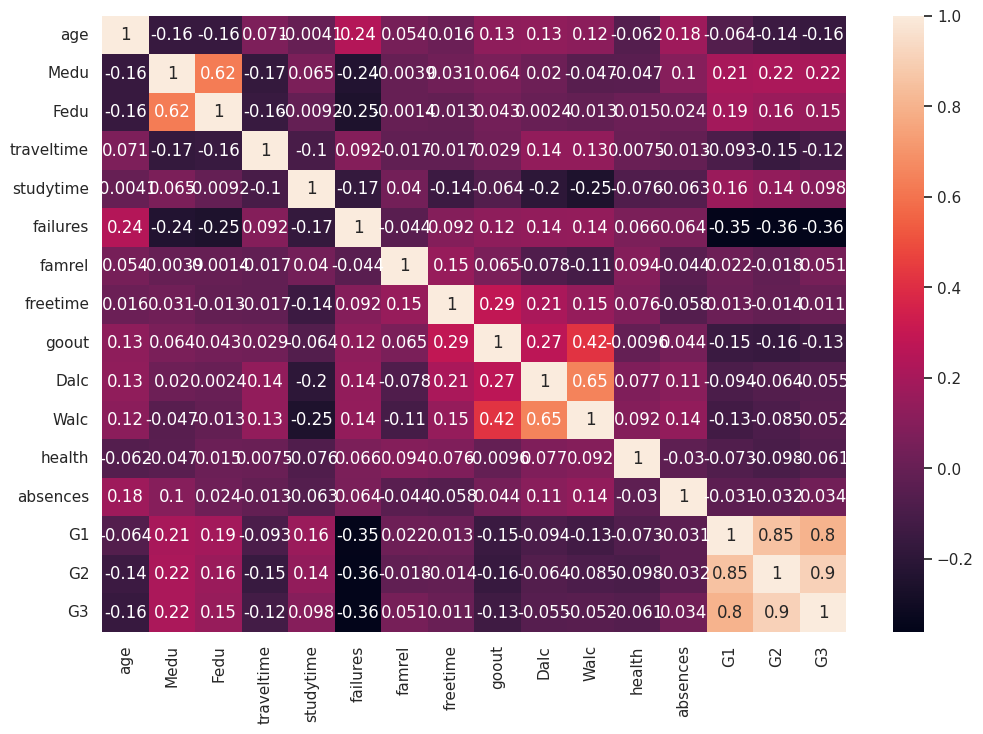

In [ ]:
# Bar graph
plt.figure(figsize=(12,8))   # increase size
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()